In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import re
# Scikit 
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet
#Pytorch 
import torchvision
import torchaudio
import torch.nn as nn
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
# show the progress bar while priting
from tqdm import tqdm

import copy
import os
import xgboost as xgb



In [2]:
df = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/contracts_with_label.csv", 
low_memory=False)

In [3]:
df.head()

,Unnamed: 0,contract_id,observation_year,contract_number,contract_name,contract_status,terminated,term_type,start_date,expiration_date,...,PPI_Value,Customs,Infrastructure,International_Shipments,Logistics_Competence,Tracking_Tracing,Timeliness,contracts_per_supplier,renegotiation_prob,target_renegotiate
0,0,9675,2018,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0
1,1,9675,2019,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0
2,2,9675,2020,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0
3,3,9675,2021,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0
4,4,9675,2022,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0


In [4]:
print(df.shape)
print(f"Number of unique contracts: {df['contract_id'].nunique()}")
print(df.info())

(9201, 74)
Number of unique contracts: 2209
<class 'pandas.DataFrame'>
RangeIndex: 9201 entries, 0 to 9200
Data columns (total 74 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         9201 non-null   int64  
 1   contract_id                        9201 non-null   int64  
 2   observation_year                   9201 non-null   int64  
 3   contract_number                    9201 non-null   int64  
 4   contract_name                      9201 non-null   str    
 5   contract_status                    9201 non-null   str    
 6   terminated                         9200 non-null   object 
 7   term_type                          8866 non-null   str    
 8   start_date                         9201 non-null   str    
 9   expiration_date                    9201 non-null   str    
 10  supplier_id                        9201 non-null   int64  
 11  supplier_number        

# Number of unique contracts per department

In [5]:

contracts_per_department = (
    df
    .groupby("department", dropna=False)["contract_id"]
    .nunique()
    .reset_index(name="unique_contract_count")
    .sort_values("unique_contract_count", ascending=False)
)

print(contracts_per_department)

                                 department  unique_contract_count
12                                      NaN                    607
7                        Packaging Material                    289
9                    Raw Materials & Energy                    281
4                  Drug Product Outsourcing                    275
8   Quality, Production Services & Supplies                    215
5                Drug Substance Outsourcing                    163
3                         Devices & Needles                    158
6                                 Logistics                     94
2              Bioprocessing and Excipients                     59
0          Alliance, Acquisitions & PPM CoE                     35
1             Bioprocessing & Raw Materials                     22
10                Strategic Sourcing US�Hub                      9
11     Strategy, Sourcing & Negotiation CoE                      2


# Rows pr. Department

In [6]:
rows_per_department = (
    df
    .groupby("department", dropna=False)
    .size()
    .reset_index(name="row_count")
    .sort_values("row_count", ascending=False)
)

print(rows_per_department)

                                 department  row_count
12                                      NaN       3050
9                    Raw Materials & Energy       1555
7                        Packaging Material       1272
8   Quality, Production Services & Supplies       1044
3                         Devices & Needles        586
4                  Drug Product Outsourcing        539
6                                 Logistics        282
0          Alliance, Acquisitions & PPM CoE        270
5                Drug Substance Outsourcing        243
2              Bioprocessing and Excipients        218
1             Bioprocessing & Raw Materials        125
10                Strategic Sourcing US�Hub         15
11     Strategy, Sourcing & Negotiation CoE          2


# Number of unique contracts per department per year

In [7]:
contracts_per_department_year_pivot = (
    df
    .groupby(["department", "observation_year"], dropna=False)["contract_id"]
    .nunique()
    .unstack(fill_value=0)
)

print(contracts_per_department_year_pivot)

observation_year                         2015  2016  2017  2018  2019  2020  \
department                                                                    
Alliance, Acquisitions & PPM CoE           11    12    15    22    24    25   
Bioprocessing & Raw Materials               6     7     7     9     9     9   
Bioprocessing and Excipients                8     8     8    10    11    18   
Devices & Needles                           9    11    14    18    25    32   
Drug Product Outsourcing                    1     1     1     1     6    11   
Drug Substance Outsourcing                  1     2     2     2     3     4   
Logistics                                   5     5     9     9     9    10   
Packaging Material                         36    39    43    52    73    91   
Quality, Production Services & Supplies    17    22    27    44    62    81   
Raw Materials & Energy                     51    66    72    88   104   115   
Strategic Sourcing US�Hub                   0     0 

# Feature Engineering

In [8]:
df_feature_engineered = df.copy()

# Stage 1: Mean Predictor, Linear BaseLine, XGBoost Baseline & MLP Baseline 

In [9]:
#Use this when we have done feature engineering
# df_baseline = df_feature_engineered

df_baseline = df.copy()

Target columns

In [10]:
target_col = "renegotiation_prob"
group_col = "contract_id"

Features to drop

In [11]:
drop_cols = [
    "Unnamed: 0",
    "contract_id",
    "contract_number",
    "contract_name",
    "supplier_id",
    "supplier_number",
    "supplier_display_name",
    "moodys_bvd_id",
    "Company name Latin alphabet",
    "target_renegotiate",
    "start_date",
    "expiration_date",
]

In [12]:
feature_cols = [c for c in df_baseline.columns if c not in drop_cols + [target_col]]

X = df_baseline[feature_cols].copy()
y = df_baseline[target_col].astype(float).copy()
groups = df_baseline[group_col].copy()

Group splitting

In [13]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_val = X.iloc[val_idx].copy()

y_train = y.iloc[train_idx].copy()
y_val = y.iloc[val_idx].copy()

train_groups = groups.iloc[train_idx].copy()
val_groups = groups.iloc[val_idx].copy()

print("Train rows:", X_train.shape[0])
print("Val rows:", X_val.shape[0])
print("Train unique contracts:", train_groups.nunique())
print("Val unique contracts:", val_groups.nunique())


Train rows: 7302
Val rows: 1899
Train unique contracts: 1767
Val unique contracts: 442


Evaluation function

In [14]:
def evaluate_predictions(y_true, y_pred, model_name="model"):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return pd.DataFrame({
        "model": [model_name],
        "rmse": [rmse],
        "mae": [mae],
        "r2": [r2],
        "pred_mean": [np.mean(y_pred)],
        "true_mean": [np.mean(y_true)]
    })

### Define what is numerical and categorical columns

In [15]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "string", "str"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numeric columns: 39
Categorical columns: 22


### Preprocssesing

In [16]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

Creating a list to store results from baseline models

In [17]:
baseline_results_list = []

baseline_val_predictions = pd.DataFrame({
    "contract_id": val_groups.values,
    "y_true": y_val.values
})

print(baseline_val_predictions.head())

   contract_id    y_true
0         8157  0.698766
1         8157  0.698766
2         8157  0.698766
3         8157  0.696954
4         8157  0.696954


## Mean predictor

In [18]:
train_mean = y_train.mean()
y_pred_mean = np.full(shape=len(y_val), fill_value=train_mean)

results_mean = evaluate_predictions(
    y_true=y_val,
    y_pred=y_pred_mean,
    model_name="Mean Predictor"
)

baseline_results_list.append(results_mean)
baseline_val_predictions["mean_predictor"] = y_pred_mean

print(results_mean)

            model      rmse       mae        r2  pred_mean  true_mean
0  Mean Predictor  0.209304  0.167898 -0.003187   0.525461   0.513663


## ElasticNet

In [19]:
elastic_net = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=42))
])

elastic_net.fit(X_train, y_train)
y_pred_enet = elastic_net.predict(X_val)

# Keep predictions within [0, 1]
y_pred_enet = np.clip(y_pred_enet, 0, 1)

results_enet = evaluate_predictions(
    y_true=y_val,
    y_pred=y_pred_enet,
    model_name="Elastic Net"
)

baseline_results_list.append(results_enet)
baseline_val_predictions["elastic_net"] = y_pred_enet

print(results_enet)

         model      rmse       mae        r2  pred_mean  true_mean
0  Elastic Net  0.129841  0.105273  0.613941   0.511151   0.513663


## MLP baseline

### Transform into Matricies & Dataloaders

In [20]:
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)

# convert sparse -> dense if needed
if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()
    X_val_proc = X_val_proc.toarray()

X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_proc, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

In [21]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

### MLP

In [22]:
class TabularMLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# ------------------------------------------------------------
# 4. Initialize model
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TabularMLP(input_dim=X_train_tensor.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ------------------------------------------------------------
# 5. Evaluation function for MLP
# ------------------------------------------------------------
def evaluate_mlp(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds = []
    targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            total_loss += loss.item() * xb.size(0)

            preds.append(out.cpu().numpy())
            targets.append(yb.cpu().numpy())

    preds = np.vstack(preds).ravel()
    targets = np.vstack(targets).ravel()

    avg_loss = total_loss / len(loader.dataset)
    rmse = mean_squared_error(targets, preds) ** 0.5
    mae = mean_absolute_error(targets, preds)

    return avg_loss, rmse, mae

# ------------------------------------------------------------
# 6. Training loop with early stopping
# ------------------------------------------------------------
best_val_loss = float("inf")
best_state_dict = None
patience = 5
patience_counter = 0

train_losses = []
val_losses = []
val_rmses = []
val_maes = []

n_epochs = 50

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_rmse, val_mae = evaluate_mlp(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_rmses.append(val_rmse)
    val_maes.append(val_mae)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Val MAE: {val_mae:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

# ------------------------------------------------------------
# 7. Restore best model
# ------------------------------------------------------------
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

# ------------------------------------------------------------
# 8. Save pretrained model BOTH in memory and locally
# ------------------------------------------------------------

# In memory: use this later directly for MAML in the same notebook session
pretrained_mlp_state_dict = copy.deepcopy(model.state_dict())

# Local save: useful for thesis reproducibility / kernel restart
save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

mlp_model_path = os.path.join(save_dir, "mlp_pretrained.pt")
torch.save(pretrained_mlp_state_dict, mlp_model_path)

print(f"Saved pretrained MLP locally to: {mlp_model_path}")
print("Pretrained MLP also stored in memory as: pretrained_mlp_state_dict")

# ------------------------------------------------------------
# 9. Final validation predictions from best model
# ------------------------------------------------------------
model.eval()
mlp_preds = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        out = model(xb)
        mlp_preds.append(out.cpu().numpy())

y_pred_mlp = np.vstack(mlp_preds).ravel()
y_pred_mlp = np.clip(y_pred_mlp, 0, 1)

# ------------------------------------------------------------
# 10. Add MLP to baseline comparison
# ------------------------------------------------------------
results_mlp = evaluate_predictions(
    y_true=y_val,
    y_pred=y_pred_mlp,
    model_name="MLP"
)

baseline_results_list.append(results_mlp)
baseline_val_predictions["mlp"] = y_pred_mlp

print(results_mlp)

# ------------------------------------------------------------
# 11. Store training history
# ------------------------------------------------------------
mlp_training_history = pd.DataFrame({
    "epoch": range(1, len(train_losses) + 1),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "val_rmse": val_rmses,
    "val_mae": val_maes
})

# Optional local save of history
mlp_history_path = os.path.join(save_dir, "mlp_training_history.csv")
mlp_training_history.to_csv(mlp_history_path, index=False)

print(f"Saved MLP training history locally to: {mlp_history_path}")
print(mlp_training_history.head())

Epoch 01 | Train Loss: 0.6471 | Val Loss: 0.6643 | Val RMSE: 0.1088 | Val MAE: 0.0842
Epoch 02 | Train Loss: 0.6266 | Val Loss: 0.6602 | Val RMSE: 0.0997 | Val MAE: 0.0748
Epoch 03 | Train Loss: 0.6227 | Val Loss: 0.6578 | Val RMSE: 0.0952 | Val MAE: 0.0689
Epoch 04 | Train Loss: 0.6187 | Val Loss: 0.6189 | Val RMSE: 0.0864 | Val MAE: 0.0595
Epoch 05 | Train Loss: 0.6165 | Val Loss: 0.6279 | Val RMSE: 0.0829 | Val MAE: 0.0569
Epoch 06 | Train Loss: 0.6144 | Val Loss: 0.6331 | Val RMSE: 0.0730 | Val MAE: 0.0469
Epoch 07 | Train Loss: 0.6129 | Val Loss: 0.6199 | Val RMSE: 0.0731 | Val MAE: 0.0452
Epoch 08 | Train Loss: 0.6113 | Val Loss: 0.6196 | Val RMSE: 0.0735 | Val MAE: 0.0479
Epoch 09 | Train Loss: 0.6106 | Val Loss: 0.6305 | Val RMSE: 0.0643 | Val MAE: 0.0390
Early stopping triggered at epoch 9
Saved pretrained MLP locally to: models/mlp_pretrained.pt
Pretrained MLP also stored in memory as: pretrained_mlp_state_dict
  model      rmse       mae        r2  pred_mean  true_mean
0   M

## XGboost

In [24]:
numeric_transformer_xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_xgb, numeric_cols),
        ("cat", categorical_transformer_xgb, categorical_cols),
    ]
)

In [25]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor_xgb),
    ("model", xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

# ------------------------------------------------------------
# 3. Fit model
# ------------------------------------------------------------
xgb_model.fit(X_train, y_train)

# ------------------------------------------------------------
# 4. Predict on validation set
# ------------------------------------------------------------
y_pred_xgb = xgb_model.predict(X_val)

# keep predictions in [0,1]
y_pred_xgb = np.clip(y_pred_xgb, 0, 1)

# ------------------------------------------------------------
# 5. Evaluate and append to baseline containers
# ------------------------------------------------------------
results_xgb = evaluate_predictions(
    y_true=y_val,
    y_pred=y_pred_xgb,
    model_name="XGBoost"
)

baseline_results_list.append(results_xgb)
baseline_val_predictions["xgboost"] = y_pred_xgb

print(results_xgb)

     model      rmse       mae        r2  pred_mean  true_mean
0  XGBoost  0.029261  0.007256  0.980393   0.513145   0.513663


In [26]:
# Get trained xgboost model out of pipeline
xgb_fitted = xgb_model.named_steps["model"]
xgb_preprocessor = xgb_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = xgb_preprocessor.get_feature_names_out()

# Build importance table
xgb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_fitted.feature_importances_
}).sort_values("importance", ascending=False)

print(xgb_importance.tail(50))

                                               feature  importance
246         cat__contract_commodity_Single Use Systems         0.0
245  cat__contract_commodity_Single Use Process Equ...         0.0
242           cat__contract_commodity_Sales Commission         0.0
241  cat__contract_commodity_SaaS (Software as a Se...         0.0
240    cat__contract_commodity_SIP (Devices & Needles)         0.0
239            cat__contract_commodity_Rubber Plungers         0.0
238            cat__contract_commodity_Rubber Laminate         0.0
237        cat__contract_commodity_Road Transportation         0.0
236    cat__contract_commodity_Rewards and Recognition         0.0
234  cat__contract_commodity_Purchase of Real Estat...         0.0
232  cat__contract_commodity_Printed Packaging Mate...         0.0
230  cat__contract_commodity_Prefilled Plastic Comp...         0.0
199      cat__contract_commodity_Lifescience Chemicals         0.0
197            cat__contract_commodity_Laundry Service        

## Compare baseline predictions

In [27]:
baseline_results = pd.concat(baseline_results_list, ignore_index=True)
baseline_results = baseline_results.sort_values("mae", ascending=True).reset_index(drop=True)

print(baseline_results)
print(baseline_val_predictions.head())

            model      rmse       mae        r2  pred_mean  true_mean
0         XGBoost  0.029261  0.007256  0.980393   0.513145   0.513663
1             MLP  0.086395  0.059534  0.829074   0.525692   0.513663
2     Elastic Net  0.129841  0.105273  0.613941   0.511151   0.513663
3  Mean Predictor  0.209304  0.167898 -0.003187   0.525461   0.513663
   contract_id    y_true  mean_predictor  elastic_net       mlp   xgboost
0         8157  0.698766        0.525461     0.601551  0.652481  0.694961
1         8157  0.698766        0.525461     0.571390  0.664139  0.694961
2         8157  0.698766        0.525461     0.541230  0.674508  0.694961
3         8157  0.696954        0.525461     0.501340  0.675943  0.694093
4         8157  0.696954        0.525461     0.471180  0.670480  0.694558


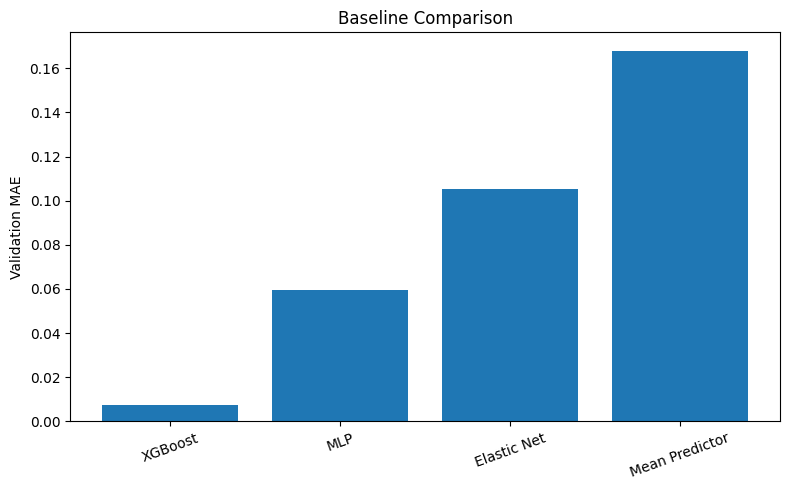

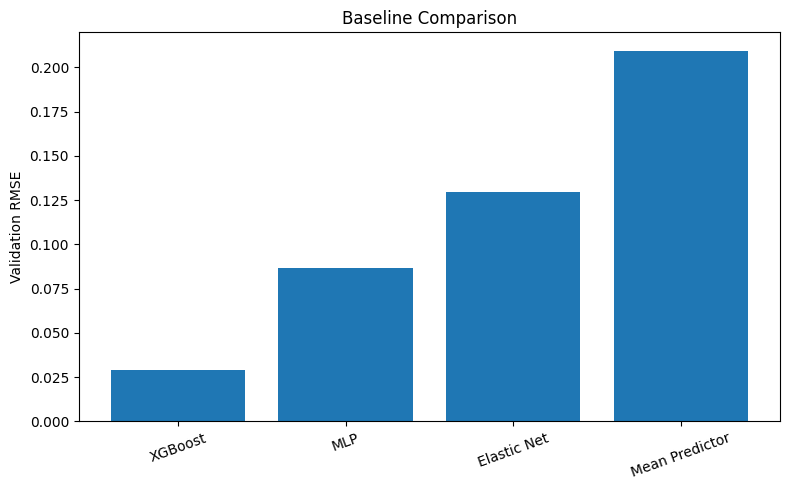

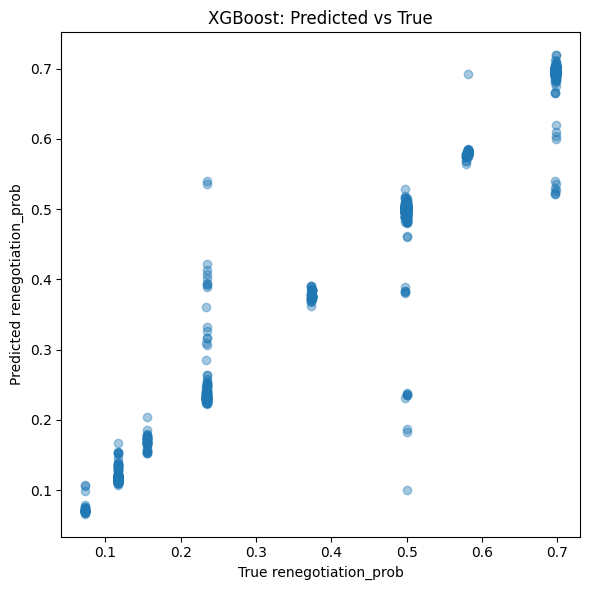

In [28]:
plot_df = baseline_results.sort_values("mae", ascending=True)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["mae"])
plt.ylabel("Validation MAE")
plt.title("Baseline Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["rmse"])
plt.ylabel("Validation RMSE")
plt.title("Baseline Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_pred_xgb, alpha=0.4)
plt.xlabel("True renegotiation_prob")
plt.ylabel("Predicted renegotiation_prob")
plt.title("XGBoost: Predicted vs True")
plt.tight_layout()
plt.show()

# Stage 2: MAMAL